# Implementacion Apriori

Cada fila del dataset se toma como una transacción y cada atributo categórico se convierte en un ítem con la forma:

COLUMNA=VALOR

Por ejemplo:

SEXO=HOMBRE
ENTIDAD=SINALOA
ESTATUS_VICTIMA=DESAPARECIDA

El objetivo es encontrar combinaciones frecuentes de atributos y después generar reglas de asociación usando soporte, confianza y lift.

No se realiza una limpieza exhaustiva del dataset, pero sí se transforman algunas variables para que puedan ser usadas por Apriori.

In [46]:
import pandas as pd
import numpy as np


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
RUTA_DATASET = "/content/drive/MyDrive/almacenesMineria/tarea03/data_secretariado.csv"

df = pd.read_csv(RUTA_DATASET, dtype=str)

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(133887, 11)


,ID_VICTIMA,ORIGEN_REPORTE,FECHA_NACIMIENTO,SEXO,FECHA_DESAPARICION,FECHA_REGISTRO,ESTATUS_VICTIMA,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO
0,D49C001E-41E4-45B7-B8FD-D867578F093E,FISCALIA GENERAL DE DURANGO,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,10,DURANGO,999,CONFIDENCIAL
1,2D2B5CD4-7AF7-48C3-887E-72F4C6403863,COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL EST...,1971-06-13,HOMBRE,2025-09-28 04:40:00,2025-09-29 10:00:00,DESAPARECIDA,25,SINALOA,004,CONCORDIA
2,6AE9098C-0C30-4709-9A2C-37F6312CD43E,PROCURADURIA GENERAL DE JUSTICIA DE LA CIUDAD ...,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,09,CIUDAD DE MÉXICO,999,CONFIDENCIAL
3,6B899D2D-F33D-4880-82CD-953FF972B9C3,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,02,BAJA CALIFORNIA,999,CONFIDENCIAL
4,3F026638-8169-4CEA-9D9A-E345B6D2D7B6,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,CONFIDENCIAL,02,BAJA CALIFORNIA,999,CONFIDENCIAL


In [49]:
print("Columnas del dataset:")
for col in df.columns:
    print(col)

Columnas del dataset:
ID_VICTIMA
ORIGEN_REPORTE
FECHA_NACIMIENTO
SEXO
FECHA_DESAPARICION
FECHA_REGISTRO
ESTATUS_VICTIMA
CVE_ENT
ENTIDAD
CVE_MUN
MUNICIPIO


## Preparación de los datos para Apriori

El dataset ya viene limpio, por lo tanto no se hará una limpieza profunda.

Lo que sí se hace es una transformación necesaria para Apriori:

- Se elimina ID_VICTIMA porque es un identificador único y no sirve para encontrar patrones generales.
- Cada fila se convierte en una transacción.

Las fechas completas no se usan directamente porque generarían demasiados valores únicos. Por eso se discretizan en año y mes, permitiendo encontrar patrones más generales.

In [50]:
data = df.copy()


INCLUIR_CONFIDENCIALES = False

if not INCLUIR_CONFIDENCIALES:
    columnas_confidenciales = ["SEXO", "ESTATUS_VICTIMA", "MUNICIPIO"]

    for col in columnas_confidenciales:
        data = data[data[col] != "CONFIDENCIAL"]

data["FECHA_DESAPARICION_DT"] = pd.to_datetime(
    data["FECHA_DESAPARICION"],
    errors="coerce"
)

data["FECHA_REGISTRO_DT"] = pd.to_datetime(
    data["FECHA_REGISTRO"],
    errors="coerce"
)

data["FECHA_NACIMIENTO_DT"] = pd.to_datetime(
    data["FECHA_NACIMIENTO"],
    errors="coerce"
)

data["ANIO_DESAPARICION"] = (
    data["FECHA_DESAPARICION_DT"]
    .dt.year
    .astype("Int64")
    .astype(str)
    .replace("<NA>", "DESCONOCIDO")
)

data["MES_DESAPARICION"] = (
    data["FECHA_DESAPARICION_DT"]
    .dt.month
    .astype("Int64")
    .astype(str)
    .str.zfill(2)
    .replace("<NA>", "DESCONOCIDO")
)

data["ANIO_REGISTRO"] = (
    data["FECHA_REGISTRO_DT"]
    .dt.year
    .astype("Int64")
    .astype(str)
    .replace("<NA>", "DESCONOCIDO")
)

# Edad aproximada al momento de desaparición
edad = (data["FECHA_DESAPARICION_DT"] - data["FECHA_NACIMIENTO_DT"]).dt.days / 365.25

# Quitamos edades poco probables
edad = edad.where((edad >= 0) & (edad <= 120))

bins = [-np.inf, 11, 17, 29, 44, 59, np.inf]
labels = ["0-11", "12-17", "18-29", "30-44", "45-59", "60+"]

data["GRUPO_EDAD"] = pd.cut(edad, bins=bins, labels=labels)
data["GRUPO_EDAD"] = data["GRUPO_EDAD"].astype(str).replace("nan", "DESCONOCIDO")

# Variables que se usarán como ítems.
# ORIGEN_REPORTE se podria agregar, pero generaria reglas muy obvias con ENTIDAD.
COLUMNAS_ITEMS = [
    "SEXO",
    "ESTATUS_VICTIMA",
    "ENTIDAD",
    "MUNICIPIO",
    "ANIO_DESAPARICION",
    "MES_DESAPARICION",
    "ANIO_REGISTRO",
    "GRUPO_EDAD"
]

data_apriori = data[COLUMNAS_ITEMS].copy()

print("Dimensiones después de preparar los datos:")
print(data_apriori.shape)

data_apriori.head()

Dimensiones después de preparar los datos:
(84738, 8)


,SEXO,ESTATUS_VICTIMA,ENTIDAD,MUNICIPIO,ANIO_DESAPARICION,MES_DESAPARICION,ANIO_REGISTRO,GRUPO_EDAD
1,HOMBRE,DESAPARECIDA,SINALOA,CONCORDIA,2025,09,2025,45-59
5,HOMBRE,DESAPARECIDA,PUEBLA,PUEBLA,2025,09,2025,0-11
7,MUJER,DESAPARECIDA,PUEBLA,PUEBLA,2025,09,2025,30-44
11,HOMBRE,DESAPARECIDA,MICHOACÁN,TINGÜINDÍN,2021,03,2021,30-44
14,HOMBRE,DESAPARECIDA,HIDALGO,PACHUCA DE SOTO,2025,09,2025,0-11


Algunas reglas son esperadas debido a relaciones jerárquicas entre variables, por ejemplo MUNICIPIO y ENTIDAD.

In [51]:
def crear_transacciones(df_items):
    transacciones = []

    for _, fila in df_items.iterrows():
        transaccion = set()

        for columna, valor in fila.items():
            if pd.notna(valor) and str(valor).strip() != "":
                item = f"{columna}={str(valor).strip()}"
                transaccion.add(item)

        transacciones.append(frozenset(transaccion))

    return transacciones


transacciones = crear_transacciones(data_apriori)

print("Número de transacciones:", len(transacciones))
print("Ejemplo de una transacción:")
transacciones[45]

Número de transacciones: 84738
Ejemplo de una transacción:


frozenset({'ANIO_DESAPARICION=2025',
           'ANIO_REGISTRO=2025',
           'ENTIDAD=TAMAULIPAS',
           'ESTATUS_VICTIMA=DESAPARECIDA',
           'GRUPO_EDAD=18-29',
           'MES_DESAPARICION=09',
           'MUNICIPIO=REYNOSA',
           'SEXO=HOMBRE'})

## Implementación

El algoritmo se implementa con los siguientes pasos:

1. Obtener los itemsets frecuentes de tamaño 1.
2. Generar candidatos de tamaño 2.
3. Calcular su soporte.
4. Conservar solamente los candidatos frecuentes.
5. Repetir el proceso para itemsets de tamaño 3, 4, etc.
6. Detenerse cuando ya no existan candidatos frecuentes.

Se usa soporte relativo, es decir:

soporte = número de transacciones que contienen el itemset / número total de transacciones

In [52]:
from math import ceil
from collections import defaultdict
from itertools import combinations

def calcular_soporte_absoluto(itemset, transacciones):
    # Calcula el soporte absoluto de un itemset.
    # Es decir, cuenta en cuántas transacciones aparece el itemset.
    # Para esto se recorre la base de transacciones.
    conteo = 0

    for transaccion in transacciones:
        if itemset.issubset(transaccion):
            conteo += 1

    return conteo

In [53]:
def obtener_itemsets_frecuentes_1(transacciones, min_soporte_absoluto):
    conteos = defaultdict(int)

    for transaccion in transacciones:
        for item in transaccion:
            itemset = frozenset([item])
            conteos[itemset] += 1

    F1 = {}
    for itemset, conteo in conteos.items():
        if conteo >= min_soporte_absoluto:
            F1[itemset] = conteo

    return F1

In [54]:
def tiene_subconjuntos_frecuentes(candidato, frecuentes_anteriores):

    #Verifica la propiedad Apriori.
    #Un candidato de tamaño k solo puede ser frecuente si todos sus subconjuntos
    #de tamaño k-1 también fueron frecuentes.

    k = len(candidato)
    frecuentes_anteriores = set(frecuentes_anteriores)

    for subconjunto in combinations(candidato, k - 1):
        subconjunto = frozenset(subconjunto)

        if subconjunto not in frecuentes_anteriores:
            return False

    return True

In [55]:
def generar_candidatos(frecuentes_anteriores, k):
    # Une itemsets frecuentes anteriores para formar candidatos de tamaño k,
    # después elimina los candidatos que no cumplen con la propiedad Apriori.

    candidatos = set()
    frecuentes_anteriores = list(frecuentes_anteriores)

    for i in range(len(frecuentes_anteriores)):
        for j in range(i + 1, len(frecuentes_anteriores)):
            candidato = frecuentes_anteriores[i] | frecuentes_anteriores[j]

            if len(candidato) == k:
                if tiene_subconjuntos_frecuentes(candidato, frecuentes_anteriores):
                    candidatos.add(candidato)

    return candidatos

In [56]:
def filtrar_candidatos_por_soporte(candidatos, transacciones, min_soporte_absoluto):
    frecuentes = {}

    for candidato in candidatos:
        conteo = calcular_soporte_absoluto(candidato, transacciones)

        if conteo >= min_soporte_absoluto:
            frecuentes[candidato] = conteo

    return frecuentes

In [57]:
def apriori(transacciones, min_support=0.02, max_k=3, mostrar_proceso=True):
    n = len(transacciones)

    if 0 < min_support < 1:
        min_soporte_absoluto = ceil(min_support * n)
    else:
        min_soporte_absoluto = int(min_support)

    soportes = {}
    conteos = {}
    frecuentes_por_nivel = {}

    if mostrar_proceso:
        print("Número de transacciones:", n)
        print("Soporte mínimo absoluto:", min_soporte_absoluto)
        print()

    # obtener F1
    k = 1
    Fk = obtener_itemsets_frecuentes_1(transacciones, min_soporte_absoluto)
    frecuentes_por_nivel[k] = Fk

    for itemset, conteo in Fk.items():
        conteos[itemset] = conteo
        soportes[itemset] = conteo / n

    if mostrar_proceso:
        print(f"F{k}: {len(Fk)} itemsets frecuentes")

    # repetir mientras existan itemsets frecuentes
    while len(Fk) > 0:
        k += 1

        if max_k is not None and k > max_k:
            break

        Ck = generar_candidatos(Fk.keys(), k)

        if mostrar_proceso:
            print(f"C{k}: {len(Ck)} candidatos generados")

        if len(Ck) == 0:
            break

        # Calcular soporte
        Fk = filtrar_candidatos_por_soporte(
            Ck,
            transacciones,
            min_soporte_absoluto
        )

        if mostrar_proceso:
            print(f"F{k}: {len(Fk)} itemsets frecuentes")

        if len(Fk) == 0:
            break

        frecuentes_por_nivel[k] = Fk

        for itemset, conteo in Fk.items():
            conteos[itemset] = conteo
            soportes[itemset] = conteo / n

    return soportes, conteos, frecuentes_por_nivel

In [58]:
MIN_SUPPORT = 0.02
MAX_K = 3

soportes, conteos, frecuentes_por_nivel = apriori(
    transacciones,
    min_support=MIN_SUPPORT,
    max_k=MAX_K,
    mostrar_proceso=True
)

print()
print("Total de itemsets frecuentes encontrados:", len(soportes))

print("\nItemsets frecuentes por tamaño:")
for k, itemsets in frecuentes_por_nivel.items():
    print(f"Tamaño {k}: {len(itemsets)}")

Número de transacciones: 84738
Soporte mínimo absoluto: 1695

F1: 81 itemsets frecuentes
C2: 3240 candidatos generados
F2: 242 itemsets frecuentes
C3: 285 candidatos generados
F3: 226 itemsets frecuentes

Total de itemsets frecuentes encontrados: 549

Itemsets frecuentes por tamaño:
Tamaño 1: 81
Tamaño 2: 242
Tamaño 3: 226


In [59]:
def itemset_a_texto(itemset):

    # Convierte un itemset en texto para mostrarlo en tablas.
    return ", ".join(sorted(itemset))


itemsets_frecuentes = []

for itemset, soporte in soportes.items():
    itemsets_frecuentes.append({
        "itemset": itemset_a_texto(itemset),
        "tamaño": len(itemset),
        "conteo_soporte": conteos[itemset],
        "soporte": soporte
    })

df_itemsets_frecuentes = pd.DataFrame(itemsets_frecuentes)

df_itemsets_frecuentes = df_itemsets_frecuentes.sort_values(
    by=["tamaño", "soporte"],
    ascending=[True, False]
)

df_itemsets_frecuentes

,itemset,tamaño,conteo_soporte,soporte
6,ESTATUS_VICTIMA=DESAPARECIDA,1,79881,0.942682
0,SEXO=HOMBRE,1,64666,0.763129
70,GRUPO_EDAD=DESCONOCIDO,1,33839,0.399337
8,SEXO=MUJER,1,19716,0.232670
9,GRUPO_EDAD=30-44,1,17817,0.210260
...,...,...,...,...
500,"ANIO_DESAPARICION=2013, ESTATUS_VICTIMA=DESAPA...",3,1712,0.020203
548,"ANIO_REGISTRO=2013, ESTATUS_VICTIMA=DESAPARECI...",3,1711,0.020192
382,"ANIO_DESAPARICION=2011, GRUPO_EDAD=DESCONOCIDO...",3,1708,0.020156
327,"ENTIDAD=SE DESCONOCE, ESTATUS_VICTIMA=DESAPARE...",3,1702,0.020085


## Generación de reglas de asociación

A partir de los itemsets frecuentes se generan reglas de asociación.

Una regla tiene la forma:

antecedente → consecuente

Por ejemplo:

SEXO=MUJER, GRUPO_EDAD=12-17 → ENTIDAD=ESTADO DE MÉXICO

Para evaluar las reglas se usan tres medidas:

- Soporte: proporción de transacciones donde aparece el antecedente junto con el consecuente.
- Confianza: proporción de veces que aparece el consecuente cuando aparece el antecedente.
- Lift: mide qué tan fuerte es la asociación entre antecedente y consecuente.

Un lift mayor que 1 indica asociación positiva; un lift igual a 1 indica independencia; y un lift menor que 1 indica asociación negativa.

In [60]:
def generar_reglas(soportes, conteos, min_confidence=0.70):
    """
    Genera reglas de asociación fuertes.

    Para cada itemset frecuente I con tamaño >= 2:
    - se generan todos sus subconjuntos no vacíos;
    - se forma la regla antecedente -> consecuente;
    - se calcula la confianza;
    - si la confianza cumple con el mínimo, se conserva la regla.

    También se calcula lift para interpretar la fuerza de asociación.
    """
    columnas = [
        "antecedente",
        "consecuente",
        "conteo_soporte",
        "soporte",
        "confianza",
        "lift"
    ]

    reglas = []

    for itemset, soporte_itemset in soportes.items():
        if len(itemset) < 2:
            continue

        items = list(itemset)

        for r in range(1, len(items)):
            for antecedente_tuple in combinations(items, r):
                antecedente = frozenset(antecedente_tuple)
                consecuente = itemset - antecedente

                soporte_antecedente = soportes.get(antecedente)
                soporte_consecuente = soportes.get(consecuente)

                if soporte_antecedente is None or soporte_consecuente is None:
                    continue

                confianza = soporte_itemset / soporte_antecedente
                lift = confianza / soporte_consecuente

                if confianza >= min_confidence:
                    reglas.append({
                        "antecedente": itemset_a_texto(antecedente),
                        "consecuente": itemset_a_texto(consecuente),
                        "conteo_soporte": conteos[itemset],
                        "soporte": soporte_itemset,
                        "confianza": confianza,
                        "lift": lift
                    })

    reglas = pd.DataFrame(reglas, columns=columnas)

    if len(reglas) > 0:
        reglas = reglas.sort_values(
            by=["confianza", "lift", "soporte"],
            ascending=False
        )

    return reglas

In [61]:
MIN_CONFIDENCE = 0.70

reglas = generar_reglas(
    soportes,
    conteos,
    min_confidence=MIN_CONFIDENCE
)

print("Total de reglas fuertes encontradas:", len(reglas))

reglas

Total de reglas fuertes encontradas: 712


,antecedente,consecuente,conteo_soporte,soporte,confianza,lift
8,MUNICIPIO=TIJUANA,ENTIDAD=BAJA CALIFORNIA,2064,0.024357,1.000000,28.199002
465,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=TIJUANA",ENTIDAD=BAJA CALIFORNIA,2051,0.024204,1.000000,28.199002
60,MUNICIPIO=CULIACÁN,ENTIDAD=SINALOA,1703,0.020097,1.000000,17.991083
33,ENTIDAD=SE DESCONOCE,MUNICIPIO=SE DESCONOCE,2369,0.027957,1.000000,15.703855
322,"ENTIDAD=SE DESCONOCE, ESTATUS_VICTIMA=DESAPARE...",MUNICIPIO=SE DESCONOCE,2349,0.027721,1.000000,15.703855
...,...,...,...,...,...,...
509,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=SE DES...",SEXO=HOMBRE,3552,0.041917,0.707993,0.927750
538,ANIO_DESAPARICION=2016,"ANIO_REGISTRO=2016, SEXO=HOMBRE",2820,0.033279,0.704472,20.613093
316,ENTIDAD=NUEVO LEÓN,"ESTATUS_VICTIMA=DESAPARECIDA, SEXO=HOMBRE",2582,0.030470,0.704118,0.981180
70,ANIO_REGISTRO=2018,SEXO=HOMBRE,3004,0.035450,0.702033,0.919941


In [62]:
reglas_simples = reglas[
    ~reglas["consecuente"].str.contains(",", na=False)
].copy()

print("Reglas con consecuente de un solo ítem:", len(reglas_simples))

reglas_simples

Reglas con consecuente de un solo ítem: 586


,antecedente,consecuente,conteo_soporte,soporte,confianza,lift
8,MUNICIPIO=TIJUANA,ENTIDAD=BAJA CALIFORNIA,2064,0.024357,1.000000,28.199002
465,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=TIJUANA",ENTIDAD=BAJA CALIFORNIA,2051,0.024204,1.000000,28.199002
60,MUNICIPIO=CULIACÁN,ENTIDAD=SINALOA,1703,0.020097,1.000000,17.991083
33,ENTIDAD=SE DESCONOCE,MUNICIPIO=SE DESCONOCE,2369,0.027957,1.000000,15.703855
322,"ENTIDAD=SE DESCONOCE, ESTATUS_VICTIMA=DESAPARE...",MUNICIPIO=SE DESCONOCE,2349,0.027721,1.000000,15.703855
...,...,...,...,...,...,...
330,"ANIO_DESAPARICION=DESCONOCIDO, MUNICIPIO=SE DE...",ANIO_REGISTRO=DESCONOCIDO,1750,0.020652,0.709651,9.862954
41,ANIO_REGISTRO=2019,ANIO_DESAPARICION=2019,3799,0.044832,0.709430,13.085702
509,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=SE DES...",SEXO=HOMBRE,3552,0.041917,0.707993,0.927750
70,ANIO_REGISTRO=2018,SEXO=HOMBRE,3004,0.035450,0.702033,0.919941


In [63]:
reglas_estatus = reglas_simples[
    reglas_simples["consecuente"].str.startswith("ESTATUS_VICTIMA", na=False)
].copy()

print("Reglas cuyo consecuente es ESTATUS_VICTIMA:", len(reglas_estatus))

reglas_estatus

Reglas cuyo consecuente es ESTATUS_VICTIMA: 230


,antecedente,consecuente,conteo_soporte,soporte,confianza,lift
688,"ANIO_REGISTRO=2024, SEXO=MUJER",ESTATUS_VICTIMA=DESAPARECIDA,2084,0.024593,1.000000,1.060803
676,"ENTIDAD=VERACRUZ, GRUPO_EDAD=DESCONOCIDO",ESTATUS_VICTIMA=DESAPARECIDA,2083,0.024582,1.000000,1.060803
548,"ANIO_DESAPARICION=2024, SEXO=MUJER",ESTATUS_VICTIMA=DESAPARECIDA,2080,0.024546,1.000000,1.060803
14,MUNICIPIO=ATLAUTLA,ESTATUS_VICTIMA=DESAPARECIDA,1835,0.021655,1.000000,1.060803
571,"ENTIDAD=ESTADO DE MÉXICO, MUNICIPIO=ATLAUTLA",ESTATUS_VICTIMA=DESAPARECIDA,1835,0.021655,1.000000,1.060803
...,...,...,...,...,...,...
134,ANIO_REGISTRO=2020,ESTATUS_VICTIMA=DESAPARECIDA,4589,0.054155,0.835275,0.886062
408,"ENTIDAD=ESTADO DE MÉXICO, MES_DESAPARICION=DES...",ESTATUS_VICTIMA=DESAPARECIDA,2381,0.028098,0.791293,0.839406
445,"ANIO_DESAPARICION=DESCONOCIDO, ENTIDAD=ESTADO ...",ESTATUS_VICTIMA=DESAPARECIDA,2381,0.028098,0.791293,0.839406
150,ENTIDAD=CHIHUAHUA,ESTATUS_VICTIMA=DESAPARECIDA,2948,0.034790,0.783834,0.831494


In [64]:
reglas_entidad = reglas_simples[
    reglas_simples["consecuente"].str.startswith("ENTIDAD", na=False)
].copy()

print("Reglas cuyo consecuente es ENTIDAD:", len(reglas_entidad))

reglas_entidad

Reglas cuyo consecuente es ENTIDAD: 10


,antecedente,consecuente,conteo_soporte,soporte,confianza,lift
8,MUNICIPIO=TIJUANA,ENTIDAD=BAJA CALIFORNIA,2064,0.024357,1.0,28.199002
465,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=TIJUANA",ENTIDAD=BAJA CALIFORNIA,2051,0.024204,1.0,28.199002
60,MUNICIPIO=CULIACÁN,ENTIDAD=SINALOA,1703,0.020097,1.0,17.991083
28,MUNICIPIO=REYNOSA,ENTIDAD=TAMAULIPAS,1716,0.020251,1.0,10.369310
521,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=REYNOSA",ENTIDAD=TAMAULIPAS,1713,0.020215,1.0,10.369310
117,MUNICIPIO=ATLAUTLA,ENTIDAD=ESTADO DE MÉXICO,1835,0.021655,1.0,7.631991
572,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=ATLAUTLA",ENTIDAD=ESTADO DE MÉXICO,1835,0.021655,1.0,7.631991
338,"GRUPO_EDAD=DESCONOCIDO, MUNICIPIO=ATLAUTLA",ENTIDAD=ESTADO DE MÉXICO,1828,0.021572,1.0,7.631991
257,"MES_DESAPARICION=DESCONOCIDO, MUNICIPIO=ATLAUTLA",ENTIDAD=ESTADO DE MÉXICO,1827,0.021561,1.0,7.631991
555,"ANIO_DESAPARICION=DESCONOCIDO, MUNICIPIO=ATLAUTLA",ENTIDAD=ESTADO DE MÉXICO,1827,0.021561,1.0,7.631991


In [65]:
def interpretar_lift(lift):
    if lift > 1:
        return "Asociación positiva"
    elif lift == 1:
        return "Independencia"
    else:
        return "Asociación negativa"


reglas_interpretadas = reglas_simples.copy()
reglas_interpretadas["interpretacion_lift"] = reglas_interpretadas["lift"].apply(interpretar_lift)

reglas_interpretadas

,antecedente,consecuente,conteo_soporte,soporte,confianza,lift,interpretacion_lift
8,MUNICIPIO=TIJUANA,ENTIDAD=BAJA CALIFORNIA,2064,0.024357,1.000000,28.199002,Asociación positiva
465,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=TIJUANA",ENTIDAD=BAJA CALIFORNIA,2051,0.024204,1.000000,28.199002,Asociación positiva
60,MUNICIPIO=CULIACÁN,ENTIDAD=SINALOA,1703,0.020097,1.000000,17.991083,Asociación positiva
33,ENTIDAD=SE DESCONOCE,MUNICIPIO=SE DESCONOCE,2369,0.027957,1.000000,15.703855,Asociación positiva
322,"ENTIDAD=SE DESCONOCE, ESTATUS_VICTIMA=DESAPARE...",MUNICIPIO=SE DESCONOCE,2349,0.027721,1.000000,15.703855,Asociación positiva
...,...,...,...,...,...,...,...
330,"ANIO_DESAPARICION=DESCONOCIDO, MUNICIPIO=SE DE...",ANIO_REGISTRO=DESCONOCIDO,1750,0.020652,0.709651,9.862954,Asociación positiva
41,ANIO_REGISTRO=2019,ANIO_DESAPARICION=2019,3799,0.044832,0.709430,13.085702,Asociación positiva
509,"ESTATUS_VICTIMA=DESAPARECIDA, MUNICIPIO=SE DES...",SEXO=HOMBRE,3552,0.041917,0.707993,0.927750,Asociación negativa
70,ANIO_REGISTRO=2018,SEXO=HOMBRE,3004,0.035450,0.702033,0.919941,Asociación negativa


## Observaciones sobre la implementación

La implementación anterior sigue la lógica clásica de Apriori: primero obtiene itemsets frecuentes de tamaño 1, después genera candidatos de tamaño mayor usando los itemsets frecuentes anteriores, calcula el soporte recorriendo la base de transacciones y conserva únicamente los candidatos que cumplen con el soporte mínimo.

Se usó un soporte mínimo de 0.02 para conservar patrones que aparezcan en una proporción suficiente del dataset. También se limitó el tamaño máximo de los itemsets a 3 para obtener reglas interpretables y evitar un crecimiento excesivo de candidatos.

Las reglas se filtraron con una confianza mínima de 0.70, siguiendo la idea de conservar únicamente reglas fuertes. Además, se calculó el lift para distinguir asociaciones positivas, independencia o asociaciones negativas.

# Algoritmos: Clasificación

## Consideraciones importantes


### Datos no válidos para el análisis
En este caso nuestro dataset todavía contiene un tipo de dato incompatible con el resto: Los datos catalogados como "Confidencial". En este caso este tipo de datos se pueden descartar sin mucha problemática, pero como observamos en la tarea anterior, estos datos opacos también son una oportunidad de extraer información al poder relacionarse con otras entradas no desconocidas (en la tarea anterior intentamos buscar una relación entre la opacidad de las entradas con la fuente de información de la cuál provienen). En este caso la limpieza del dataset envuelve a todas las columnas no validas bajo el mismo grupo de "Confidencial", así que tenemos eso en cuenta  la hora de crear nuestro modelo

### Datos no manipulables directamente

A la hora de querer construir un modelo de predicción, hay ciertos datos los cuáles no pueden ser procesados por este modelo directamente, en este caso
las fechas son fragmentos de información que pueden ser de utilidad, pero no pueden ser directamente procesados por un modelo que se base directamente en valores numéricos. En ese caso lo que hacemos es transformar las fechas en información numérica relevante, por ejemplo, en la edad de la persona al momento de desaparecer.
Adicionalmente podemos extraer otro conjunto de datos que puede ser relevante, como el tiempo de retraso entre la fecha de la desaparición y registro; aunque cabe notar que el análisis realizado en la tarea anterior nos indica que la fuerte cantidad de anomalías dentro de estas entradas puede generar inconsistencias en nuestro modelo.

Nota adicional: De manera adicional, verificaremos que todas las fechas conserven el mismo formato antes de hacer la operación, esto es solo verificación, ya que suponemos que es un dataset limpio que conwserva las fechas con el mismo formato

### Municipios
México cuenta con más de 2400 municipios, tenemos 133,888 entradas en nuestro dataset. Sería importante considerar los municipios para las predicciones que haga nuestro modelo, pero esto lo tornará increiblemente complejo al tener que considerar ahora los más de 2400 municipios, pero retomemos el hecho de que tenemos más de 133 mil entradas, si tuvieramos una distribución uniforme, cada una de las entradas tendría aproximadamente 60 entradas, pero al haber analizado este dataset anteriormente, sabemos que algunos estados y sus respectivos municipios concentran los casos de desparaiciones, haciendo que muchos municipios tengan tan pocas entradas que no vale la pena ni siquiera considerarlos para nuestro modelo.

Por el motivo anterior, consideramos adecuado el no considerar los municipios, ya que incrementaría la complejidad del modelo y los tiempos de entrenamiento a cambio de información parecida a un enfoque limitado a las Entidades.

## Modelo de predicción

### Preparación
A continuación declaramos las librerías que se usaron en nuestro modelo y que fueron especificadas como válidas para la tarea.
Así como la revisión de consistencia entre nuestras entradas de fechas para posteriormente conseguir información relevante como la edad y días de retraso.


In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# El nombre del dataset que estamos usando


#  Manejo de Fechas
# Aseguramos que sean datetime, esti es un hecho al ser un dataset limpio, no está demás hacer una comprobación
cols_fechas = ['FECHA_NACIMIENTO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO']
for col in cols_fechas:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculamos Edad y Retraso (y rellenamos valores nulos numéricos con la mediana, en ambos casos se mantiene un valor consistente)
df['EDAD'] = (df['FECHA_DESAPARICION'] - df['FECHA_NACIMIENTO']).dt.days // 365
df['EDAD'] = df['EDAD'].fillna(df['EDAD'].median())

df['RETRASO_REGISTRO'] = (df['FECHA_REGISTRO'] - df['FECHA_DESAPARICION']).dt.days
df['RETRASO_REGISTRO'] = df['RETRASO_REGISTRO'].fillna(df['RETRASO_REGISTRO'].median())

/tmp/ipykernel_5967/2708271302.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_5967/2708271302.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_5967/2708271302.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Ahora hacemos la selección de una variable objetivo, veremos si los resultados dados dentro de nuestras columnas determinan el resultado de nuestra varible objetivo y si este es el caso, buscamos la forma de predecir el resultado de nuestra variable objetivo mediante estos datos

In [67]:
# SELECCIÓN DE VARIABLES (X e y)
# Codificamos la variable objetivo (ESTATUS_VICTIMA) a números (0, 1, 2...)
le = LabelEncoder()
y = le.fit_transform(df['ESTATUS_VICTIMA'])

# Seleccionamos variables predictoras y aplicamos variables Dummies para las categóricas
#Recordemos que las variables originales son ID_VICTIMA ORIGEN_REPORTE FECHA_NACIMIENTO SEXO FECHA_DESAPARICION FECHA_REGISTRO ESTATUS_VICTIMA CVE_ENT ENTIDAD CVE_MUN MUNICIPIO
# Eliminamos las cuáles no interfieren con el resultado y otras que hacen innecesariamente más complejo nuestro resultado
# Podemos usar los CVE y Entidad sin problema, ya que representan lo mismo, en este caso usamos solo Entidad para no tener confusiones.
columnas_predictoras = ['ORIGEN_REPORTE', 'SEXO', 'ENTIDAD', 'EDAD', 'RETRASO_REGISTRO']
X = pd.get_dummies(df[columnas_predictoras])

### Entrenamiento
Ahora es el momento de crear nuestro modelo, todo el material de información que reunimos en la fase de preparación ahora podemos usarlo para entrenamiento. En primer lugar debemos de reservar cierta parte de la información para tanto entrenar nuestro modelo, como para verificar sus resultados. Primero reservamos el 70% del volumen de datos para entrenar al modelo y el otro 30% para verificar los resultados de la variable objetivo.

Después hacemos la configuración del modelo con el método de Random Forest. Cosnhstruimos 100 "arboles" que harán la predicción de la variable objetivo, además de asignar un peso "automático" para evitar el sesgo en el entrenamiento.

Lo siguiente es simplemente empezar el entrenamiento, el modelo evalua las variables predictoras y busca alguna métrica que las relacione con la variable objetivo

In [68]:
# Dividimos 70% entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ENTRENAMIENTO DEL MODELO (Random Forest)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

Después hacemos la evaluación del entrenamiento comparando las predicciones de la variable objetivo con los resultados reales. Hacemos la impresión del modelo con la precisión de cada uno de los resultados, la precisión en la detección de registros con cierto resultado (recall) y el promedio armonizado de la precisión y el recall, lo cuál nos da una idea un tanto más exacta del sesgo en nuestros sistemas y como puede estar afectando las predicciones.

Finalmente solo necesitamos exponer el total de aciertos.

In [69]:
# EVALUACIÓN Y MÉTRICAS
y_pred = modelo_rf.predict(X_test)
print("--- Reporte de Clasificación ---")
#  Precision, Recall y F1-Score por cada clase
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Accuracy Global: {accuracy_score(y_test, y_pred):.4f}")

--- Reporte de Clasificación ---
               precision    recall  f1-score   support

 CONFIDENCIAL       1.00      1.00      1.00     14735
 DESAPARECIDA       0.98      0.84      0.90     23970
NO LOCALIZADA       0.22      0.73      0.34      1462

     accuracy                           0.89     40167
    macro avg       0.73      0.86      0.75     40167
 weighted avg       0.96      0.89      0.92     40167

Accuracy Global: 0.8942


###

### Importancia de las variables para la predicción del modelo
Una de las ventajas de usar estas bibliotecas para la creación de nuestro modelo es que nos proporcionan las herramientas para observar que tan importante son algunas de las variables para las predicciones de nuestro modelo. A continuación presentamos las 10 más importantes para este caso.

/tmp/ipykernel_5967/203572410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_top, y=importancias_top.index, palette='viridis')


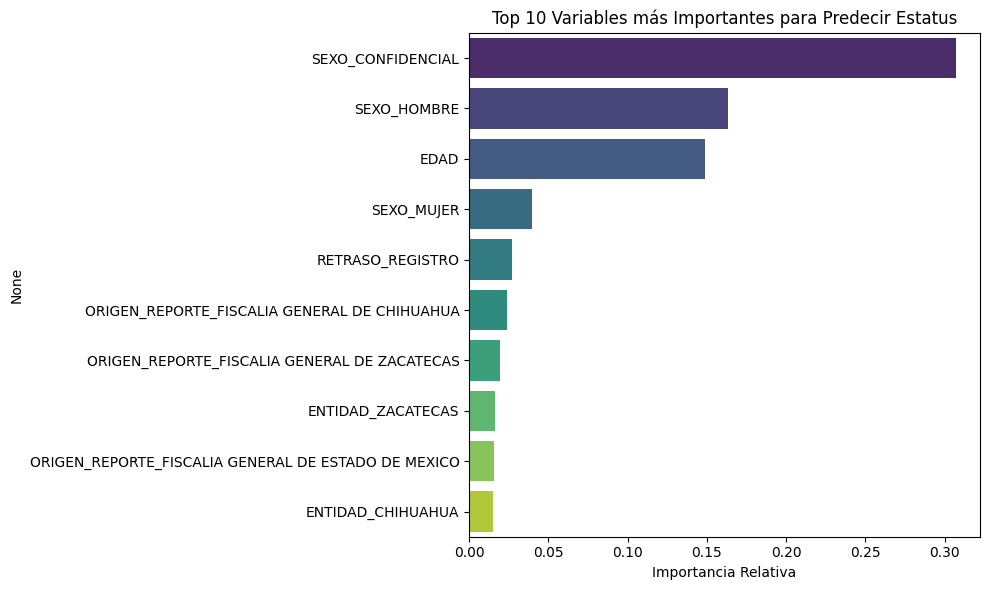

In [70]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias_top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias_top, y=importancias_top.index, palette='viridis')
plt.title('Top 10 Variables más Importantes para Predecir Estatus')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

En está sección podemos osbervar cuáles fueron las variables que más intervienen en las predicciones. Esto tiene gran utilidad para encontrar sesgos, en este caso podemos ver claramente uno de estos con la confidencialidad. Recordemos que el dataset limpio cotiene como únicos resultados para el Estatus de la victima: Confidencial, Desaparecida y No Localizada. En este caso vemos que SEXO_CONFIDENCIAL interviene en gran medida en nuestros resultados, esto se debe a que la gran mayoria de las entradas que se tienen llenadas como 'CONFIDENCIALES' también tienen los estatus como confidenciales. El resto de variables solo indica la influencia que tienen algunos resultados para que una persona siga desaparecida o no localizada. Notamos que en general la influencia de la mayoría es pequeña, esto indica que es mucho más dificil determinar llegar a una predicción tomando como base solo unos factores y mucho factores intervienen en el resultado de la variable objetivo.

#### Un sesgo importante
Eso si, es necesario notar también los orígenes de los reportes que aparecen como variables importantes, si recordamos observaciones previamente hechas en la tarea anterior, sabemos que dependiendo del lugar de expedición de la ficha de desaparición, es más probable que la informaci´ón esté o no clasificada, en este caso es interesante que las fiscalías de Chihuahua, Zacatecas y Estado de México aparezcan, puesto que son los orígenes que tienen más y menos censura en la expedición de sus registros.


## Justificaciones adicionales

### Parámetro Balanced
¿Por qué usamos el parámetro class_weight='balanced' en el modelo? Porque en fenómenos sociales graves, los datos suelen estar desbalanceados. Al tener una gran cantidad de entradas con unos pocos resultados, intentamos tener la menor cantidad de sesgo que afecte nuestras predicciones, lo que hace la opción de balanceo es ajustar de manera automática los pesos, haciendo que

### Métricas elegidas. Accuracy (Exactitud) vs. Recall (Sensibilidad):
Ac Si el 80% de las víctimas en tu base tienen estatus "Localizado", un modelo tonto que siempre diga "Localizado" tendrá un 80% de Accuracy, pero será inútil, ya que realmente no está realizando predicciones, por eso, a pesar de que la presición es una métrica importante, es necesario realizar un recuento de los registeros que realmente poseen la variable objetivo predicha del modelo (recall) para verificar que todos los casos son tomados en cuenta y no estamos omitiendo como un modelo tonto.

Podemos también argumentar que en un sistema de búsqueda gubernamental, un falso positivo (decir que alguien está localizado cuando no lo está) tiene un costo humano incalculable. Maximizar el Recall para la clase "Aún Desaparecido" asegura que el sistema identifique a la mayor cantidad posible de personas en riesgo real, minimizando las omisiones fatales; por eso son tan importantes las métricas que escogimos, especialmente recall y f1, pues a pesar de que los promedios nos dan un resultado general y relativamente preciso, es necesario tener un monitoreo constante de los casos anómalos y resultados imprecisos para asegurarnos de dar los resultados más correctos posibles.


